<a href="https://colab.research.google.com/github/ishita2740/ChainMind/blob/main/IPL_Crunch_2026_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏏 IPL Crunch '26 — Match Intelligence & Performance Analytics

> **Dataset:** IPL Ball-by-Ball Match Data

> **Objective:** Uncover toss impact, match-winning patterns, phase impact, player dominance, and hidden strategic insights using Python.

This project combines sports analytics, storytelling, and data visualization to transform raw IPL data into strategic cricket intelligence.


---

### 🎯 Key Questions This Notebook Answers
| # | Question |
|---|----------|
| 1 | Does winning the toss actually help you win the match? |
| 2 | Which phase — Powerplay, Middle Overs, or Death Overs — impacts victory the most? |
| 3 | Who are the top batters and bowlers across IPL seasons? |
| 4 | What hidden patterns exist in IPL data that most people overlook? |

---

### ===================================================
## 📦 Section 1 — Environment Setup & Library Imports
### ===================================================

In [ ]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Utilities
import warnings
warnings.filterwarnings("ignore")

# Theme & Styling

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "font.size": 11
})

# IPL Theme Colors
IPL_COLORS = [
    "#F97316",  # Orange
    "#3B82F6",  # Blue
    "#22C55E",  # Green
    "#EF4444",  # Red
    "#A855F7",  # Purple
    "#EAB308",  # Yellow
    "#06B6D4",  # Cyan
    "#EC4899"   # Pink
]

print("✅ Environment Ready")

✅ Environment Ready


### ===================================================
## 💾 Section 2 —  DATA LOADING (GOOGLE DRIVE)
### ===================================================

### 🎯 Objective

Load IPL dataset from Google Drive into the Colab environment for further analysis.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset

DATA_PATH = "/content/drive/MyDrive/IPL_CRUNCH_2026/ipl_matches.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

print("✅ Dataset loaded successfully")

✅ Dataset loaded successfully


### ===================================================
## 🔍 Section 3 — Dataset Exploration
### ===================================================

### 🎯 Objective

Understand the structure of the IPL dataset before performing any analysis.

Inspecting:
- Number of rows and columns
- Column names
- Sample records
- Missing values
- Duplicate records

This ensures working with clean and well-understood data.

In [ ]:
# First 5 rows

df.head()

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


In [ ]:
# Last 5 rows

df.tail()

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
289668,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,...,Vijaykumar Vyshak,0,1,1,1,0,0,0,NaN,NaN
289669,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,...,Vijaykumar Vyshak,4,0,4,0,0,0,0,NaN,NaN
289670,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,...,Vijaykumar Vyshak,0,1,1,1,0,0,0,NaN,NaN
289671,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,...,Vijaykumar Vyshak,6,0,6,0,0,0,0,NaN,NaN
289672,1529292,2026-05-06,2026,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Hyderabad,Sunrisers Hyderabad,Punjab Kings,Punjab Kings,field,...,Vijaykumar Vyshak,0,0,0,0,0,0,0,NaN,NaN


In [ ]:
# Dataset Shape

print("📌 Shape of dataset:")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

📌 Shape of dataset:
Rows    : 289673
Columns : 30


In [ ]:
# Column names (clean vertical display)

print("📌 Column Names:\n")

for col in df.columns:
    print("-", col)

📌 Column Names:

- match_id
- date
- season
- event
- venue
- city
- team1
- team2
- toss_winner
- toss_decision
- winner
- win_by_runs
- win_by_wickets
- player_of_match
- innings
- batting_team
- over
- ball
- batter
- bowler
- non_striker
- runs_batter
- runs_extras
- runs_total
- extras_wides
- extras_noballs
- extras_byes
- extras_legbyes
- wicket_kind
- wicket_player_out


In [ ]:
# Data info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           289673 non-null  int64  
 1   date               289673 non-null  object 
 2   season             289673 non-null  object 
 3   event              289673 non-null  object 
 4   venue              289673 non-null  object 
 5   city               277276 non-null  object 
 6   team1              289673 non-null  object 
 7   team2              289673 non-null  object 
 8   toss_winner        289673 non-null  object 
 9   toss_decision      289673 non-null  object 
 10  winner             289673 non-null  object 
 11  win_by_runs        133547 non-null  float64
 12  win_by_wickets     151146 non-null  float64
 13  player_of_match    288845 non-null  object 
 14  innings            289673 non-null  int64  
 15  batting_team       289673 non-null  object 
 16  ov

In [ ]:
# Missing values summary

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing %", ascending=False)

missing_df

,Missing Count,Missing %
wicket_kind,275267,95.03
wicket_player_out,275267,95.03
win_by_runs,156126,53.90
win_by_wickets,138527,47.82
city,12397,4.28
player_of_match,828,0.29


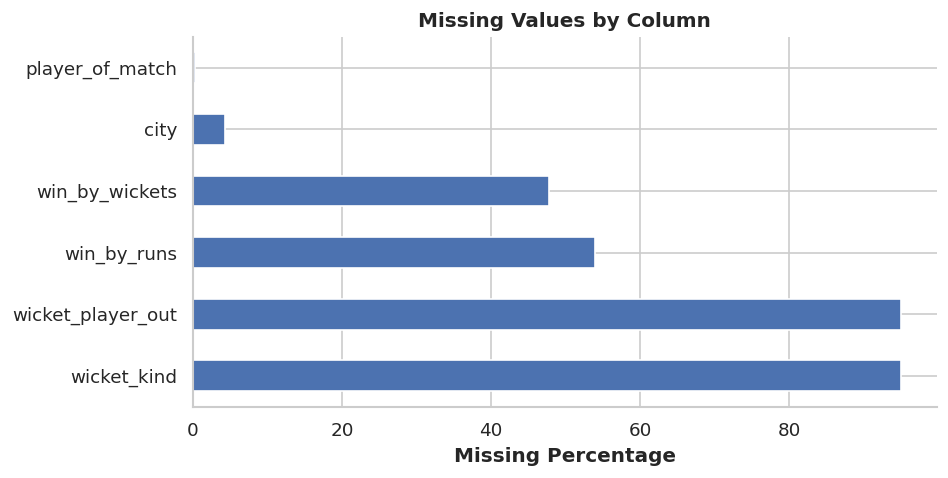

In [ ]:
import matplotlib.pyplot as plt

missing_df["Missing %"].plot(
    kind="barh",
    figsize=(8, 4),
    title="Missing Values by Column"
)

plt.xlabel("Missing Percentage")
plt.show()

In [ ]:
# Duplicate rows

print("📌 Duplicate Rows:", df.duplicated().sum())

📌 Duplicate Rows: 0


### 🧠 Key Observations

- 289,673 deliveries with 30 features (full IPL ball-by-ball data)
- No duplicate rows found
- Date column needs conversion to datetime format

- `wicket_kind` and `wicket_player_out`: Not true missing values, represent non-wicket deliveries
- `win_by_runs` and `win_by_wickets`: Complementary fields; nulls represent alternate win conditions
- `city`: True missing values due to incomplete venue metadata
- `player_of_match`: Minor missing values, likely from abandoned or incomplete matches
- Number of matches are highest in the year 2009

### ===================================================
## 🧹 Section 4 — Data Cleaning & Feature Engineering
### ===================================================

### 🎯 Objective

Prepare the raw IPL dataset for accurate analysis by:
 - Converting date to datetime
 - Engineering match-phase labels (Powerplay / Middle / Death)
 - Creating cricket-specific analytical features
 - Building metrics required for advanced sports analytics
 - Cleaning inconsistent or missing values

These engineered features will later help uncover:

- Toss impact on winning
- Match phase dominance
- Batter and bowler efficiency
- Strategic winning patterns in IPL matches

In [ ]:
# HANDLE MISSING VALUES

# If match not won by runs/wickets,
# replace missing values with 0
df["win_by_runs"] = df["win_by_runs"].fillna(0)
df["win_by_wickets"] = df["win_by_wickets"].fillna(0)

# Fill missing city names
df["city"] = df["city"].fillna("Unknown")

# Fill missing player of match
df["player_of_match"] = df["player_of_match"].fillna("Not Available")

print("✅ Missing values handled successfully")

✅ Missing values handled successfully


In [ ]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract useful date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print("✅ Date column converted successfully")

✅ Date column converted successfully


In [ ]:
# Find minimum and maximum year in dataset
start_year = df['year'].min()
end_year = df['year'].max()

print(f"IPL data is present from {start_year} to {end_year}")
print(f"Total years of data: {end_year - start_year + 1}")

IPL data is present from 2008 to 2026
Total years of data: 19


In [ ]:
# IPL T20 over structure:
#   Powerplay : overs  0–5   (overs 1–6  in 1-indexed)
#   Middle     : overs  6–14  (overs 7–15)
#   Death      : overs 15–19  (overs 16–20)

def assign_phase(over):
    if over <= 5:
        return "Powerplay"
    elif over <= 14:
        return "Middle Overs"
    else:
        return "Death Overs"

df["phase"] = df["over"].apply(assign_phase)
print("✅ Phase column created")

✅ Phase column created


In [ ]:
# verify the Phase column
df.head()

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out,year,month,phase
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,0,0,0,0,0,NaN,NaN,2017,4,Powerplay
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,0,0,0,0,0,NaN,NaN,2017,4,Powerplay
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,4,0,0,0,0,NaN,NaN,2017,4,Powerplay
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,0,0,0,0,0,NaN,NaN,2017,4,Powerplay
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,2,2,0,0,0,NaN,NaN,2017,4,Powerplay


In [ ]:
# CREATE MATCH-LEVEL DATAFRAME FOR TOSS ANALYSIS

# In the original IPL dataset:
# - Each row usually represents ONE BALL
# - A single match can therefore have hundreds of rows

# For toss analysis, we only need ONE ROW PER MATCH.
# So we remove duplicate rows based on match_id.

match_df = df.drop_duplicates(subset="match_id")[[

    "match_id",
    "date",
    "season",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "winner"

]].copy()   # Creates a safe independent dataframe


# CREATE NEW COLUMN:
# DID THE TOSS WINNER ALSO WIN THE MATCH?

match_df["toss_won_match"] = (
    match_df["toss_winner"] == match_df["winner"]
)

# This column will contain:
# True  -> Toss winner also won the match
# False -> Toss winner lost the match

print(f"✅ Match-level dataframe created — {len(match_df):,} unique matches")

print(match_df.head())

✅ Match-level dataframe created — 1,218 unique matches
     match_id       date season                        team1  \
0     1082591 2017-04-05   2017          Sunrisers Hyderabad   
248   1082592 2017-04-06   2017       Rising Pune Supergiant   
495   1082593 2017-04-07   2017                Gujarat Lions   
713   1082594 2017-04-08   2017              Kings XI Punjab   
960   1082595 2017-04-08   2017  Royal Challengers Bangalore   

                           team2                  toss_winner toss_decision  \
0    Royal Challengers Bangalore  Royal Challengers Bangalore         field   
248               Mumbai Indians       Rising Pune Supergiant         field   
495        Kolkata Knight Riders        Kolkata Knight Riders         field   
713       Rising Pune Supergiant              Kings XI Punjab         field   
960             Delhi Daredevils  Royal Challengers Bangalore           bat   

                          winner  toss_won_match  
0            Sunrisers Hyderabad  

In [ ]:
# FILTER LAST 5 IPL SEASONS

# Get all IPL seasons in sorted order
all_seasons = sorted(df["season"].unique())

# Select latest 5 seasons
last_5_seasons = all_seasons[-5:]

print("📌 Last 5 Seasons:", last_5_seasons)


# Create filtered delivery-level dataframe
# (only last 5 seasons)
df_5s = df[df["season"].isin(last_5_seasons)].copy()

# Create filtered match-level dataframe
# (only last 5 seasons)
match_5s = match_df[match_df["season"].isin(last_5_seasons)].copy()

# Display total records
print("Deliveries:", len(df_5s))
print("Matches:", len(match_5s))

📌 Last 5 Seasons: ['2022', '2023', '2024', '2025', '2026']
Deliveries: 81631
Matches: 342


In [ ]:
# SANITY CHECKS

# Check toss decision distribution
print("\n📌 Toss Decisions:")
print(match_df["toss_decision"].value_counts())

# Check phase distribution
print("\n📌 Match Phases:")
print(df["phase"].value_counts())


📌 Toss Decisions:
toss_decision
field    803
bat      415
Name: count, dtype: int64

📌 Match Phases:
phase
Middle Overs    132841
Powerplay        91014
Death Overs      65818
Name: count, dtype: int64


In [ ]:
# Extract starting year from season column
df["season"] = df["season"].astype(str).str[:4].astype(int)

print("✅ Season column converted to integer")

✅ Season column converted to integer


In [ ]:
# Required Run Rate Pressure

df["is_boundary"] = df["runs_batter"].isin([4,6])

df["is_dot"] = df["runs_total"] == 0

df["is_wicket"] = df["wicket_player_out"].notna()

In [ ]:
# Pressure Index

pressure_map = {
    "Powerplay": 1,
    "Middle Overs": 2,
    "Death Overs": 3
}

df["pressure_index"] = df["phase"].map(pressure_map)

### 🧠 PREPROCESSING SUMMARY

Key actions performed:
- Handled important missing values
- Converted date column to datetime
- Created match phase categories
- Built match-level dataset for toss analysis
- Filtered last 5 IPL seasons for player analysis
- Verified data quality using sanity checks
- IPL data is available from **2008 to 2026**
- Total IPL coverage: **19 seasons**

Dataset is now ready for visualization and insights.

### ===========================================================
## 🪙 Section 5 — ANALYSIS 1: TOSS IMPACT ON MATCH OUTCOME
### ===========================================================

### 🎯 Objective
- Determine whether winning the toss gives a team a statistically meaningful edge in winning the match.
- It is also break in down by toss decision (bat / field).

In [ ]:
# Overall toss win rate
# Measures how often toss winners actually win the match

toss_win_rate = match_df["toss_won_match"].mean() * 100
toss_loss_rate = 100 - toss_win_rate

#  Win rate by toss decision
# Checks whether choosing bat or field impacts match result

decision_winrate = (
    match_df.groupby("toss_decision")["toss_won_match"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"toss_won_match": "win_rate_%"})
)

# Season-wise trend (for deeper pattern detection)
# Helps identify whether toss impact changes across IPL seasons

season_toss = (
    match_df.groupby("season")["toss_won_match"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"toss_won_match": "win_rate_%"})
)

# print insights

print("OVERALL TOSS IMPACT")
print("Toss Winner Win Rate:", round(toss_win_rate, 1), "%")
print("Toss Loser Win Rate:", round(toss_loss_rate, 1), "%")

print("\nWIN RATE BY TOSS DECISION")
print(decision_winrate.to_string(index=False))

OVERALL TOSS IMPACT
Toss Winner Win Rate: 50.5 %
Toss Loser Win Rate: 49.5 %

WIN RATE BY TOSS DECISION
toss_decision  win_rate_%
          bat        44.3
        field        53.7


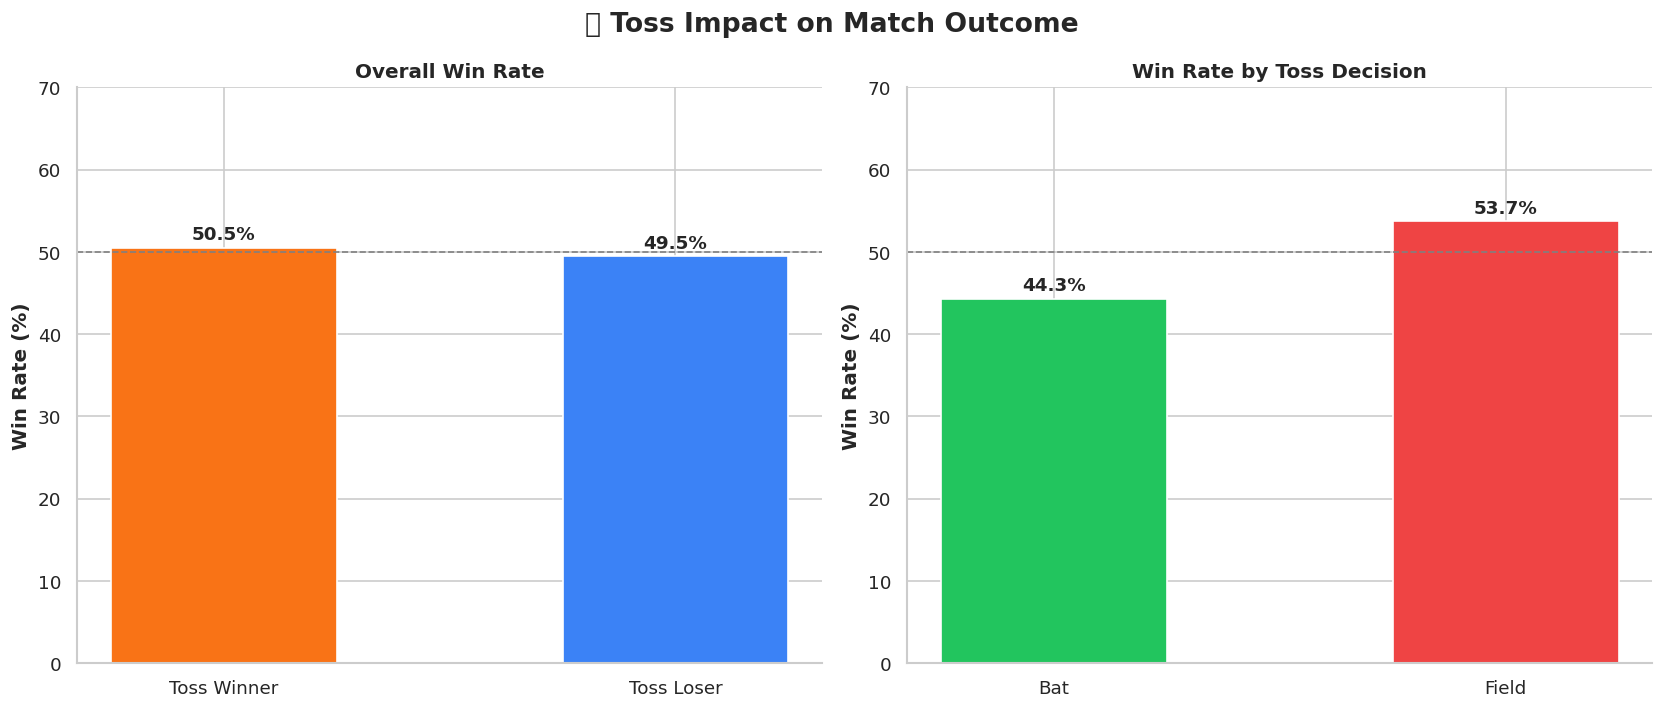

✅ Saved: chart1_toss_impact.png


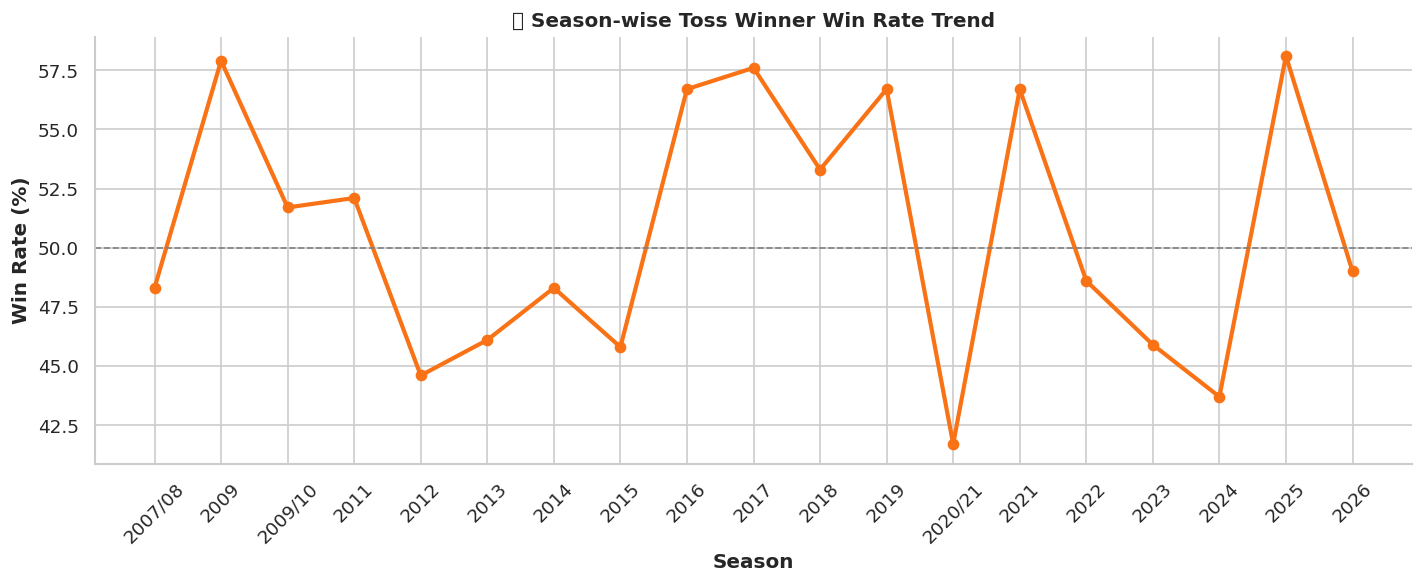

In [ ]:
# Visualization: Toss Impact

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("🪙 Toss Impact on Match Outcome", fontsize=16, fontweight="bold")

# --- Left Plot: Toss Winner vs Loser ---
categories = ["Toss Winner", "Toss Loser"]
values = [toss_win_rate, toss_loss_rate]
colors_bar = [IPL_COLORS[0], IPL_COLORS[1]]

bars = axes[0].bar(
    categories,
    values,
    color=colors_bar,
    width=0.5,
    edgecolor="white"
)

axes[0].axhline(50, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Overall Win Rate")
axes[0].set_ylabel("Win Rate (%)")
axes[0].set_ylim(0, 70)

for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        fontweight="bold"
    )


# --- Right Plot: Toss Decision ---
dec_labels = decision_winrate["toss_decision"].str.capitalize()
dec_vals = decision_winrate["win_rate_%"]
dec_colors = [IPL_COLORS[2], IPL_COLORS[3]]

bars2 = axes[1].bar(
    dec_labels,
    dec_vals,
    color=dec_colors,
    width=0.5,
    edgecolor="white"
)

axes[1].axhline(50, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Win Rate by Toss Decision")
axes[1].set_ylabel("Win Rate (%)")
axes[1].set_ylim(0, 70)

for bar, val in zip(bars2, dec_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("chart1_toss_impact.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Saved: chart1_toss_impact.png")

# --- Season-wise trend line ---

fig2, ax2 = plt.subplots(figsize=(12, 5))

ax2.plot(
    season_toss["season"],
    season_toss["win_rate_%"],
    marker="o",
    linewidth=2.5,
    color=IPL_COLORS[0]
)

ax2.axhline(50, color="gray", linestyle="--", linewidth=1)

ax2.set_title("📈 Season-wise Toss Winner Win Rate Trend")
ax2.set_xlabel("Season")
ax2.set_ylabel("Win Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🧠 Toss Impact - Key Insights

- 🪙 Toss Winner Win Rate: **50.5%**
- 🪙 Toss Loser Win Rate: **49.5%**

👉 The toss has **negligible impact** on match outcomes.

---

### 📌 Decision Insight
- Bat: **44.3%**
- Field: **53.7%**

👉 Fielding first shows a slight edge, but not a decisive one.

---

### 🏁 Final Verdict
Winning the toss does **not determine match results** — performance on the field does.

Only 0.5% points above the 50% coin-flip baseline,
So, Winning the toss provides a marginal edge,
but it is NOT a decisive factor in match outcome.
Teams win roughly half the time regardless of toss.



### ===========================================================
## 🏏 Phase Impact on Match Outcome
### ===========================================================

This analysis explores how different phases of a T20 match  
(Powerplay, Middle Overs, and Death Overs) influence match results.

### 🎯 Objective
- To identify which phase shows the **largest performance gap
between winners and losers**.

- Compare the average runs scored by match winners and losers across phases and compute the **run advantage**.

- 👉 The phase with the highest run advantage is the most **decisive phase of the match**. Teams that consistently outperform opponents in that phase are more likely to win.

In [ ]:
# Tag each delivery with win/loss for batting team
# We need: for each ball, did the batting team WIN the match?

df_innings1 = df[df["innings"] == 1].copy()   # 1st innings only for clean comparison
df_innings2 = df[df["innings"] == 2].copy()   # 2nd innings

# Merge match winner into ball-by-ball data
df_tagged = df.merge(
    match_df[["match_id", "winner"]],
    on="match_id", how="left", suffixes=("", "_match")
)

df_tagged["batting_won"] = (
    df_tagged["batting_team"] == df_tagged["winner"]
)

# Average runs per phase: winners vs losers

phase_runs = (
    df_tagged.groupby(["match_id", "phase", "batting_team", "batting_won"])["runs_total"]
    .sum()
    .reset_index()
    .rename(columns={"runs_total": "phase_runs"})
)

phase_summary = (
    phase_runs.groupby(["phase", "batting_won"])["phase_runs"]
    .mean()
    .round(1)
    .reset_index()
)

phase_summary["outcome"] = phase_summary["batting_won"].map(
    {True: "Winners", False: "Losers"}
)

print("\n📌 Average Phase Runs — Winners vs Losers:")
print(phase_summary[["phase", "outcome", "phase_runs"]].to_string(index=False))

# Phase run differential (Winners − Losers)

phase_pivot = phase_summary.pivot(
    index="phase", columns="outcome", values="phase_runs"
).reset_index()

phase_pivot["run_advantage"] = phase_pivot["Winners"] - phase_pivot["Losers"]

phase_pivot = phase_pivot.sort_values("run_advantage", ascending=False)

print("\n📌 Run Advantage of Winners by Phase:")
print(phase_pivot[["phase", "Winners", "Losers", "run_advantage"]].to_string(index=False))


📌 Average Phase Runs — Winners vs Losers:
       phase outcome  phase_runs
 Death Overs  Losers        43.5
 Death Overs Winners        47.2
Middle Overs  Losers        66.5
Middle Overs Winners        74.3
   Powerplay  Losers        45.5
   Powerplay Winners        51.3

📌 Run Advantage of Winners by Phase:
       phase  Winners  Losers  run_advantage
Middle Overs     74.3    66.5            7.8
   Powerplay     51.3    45.5            5.8
 Death Overs     47.2    43.5            3.7


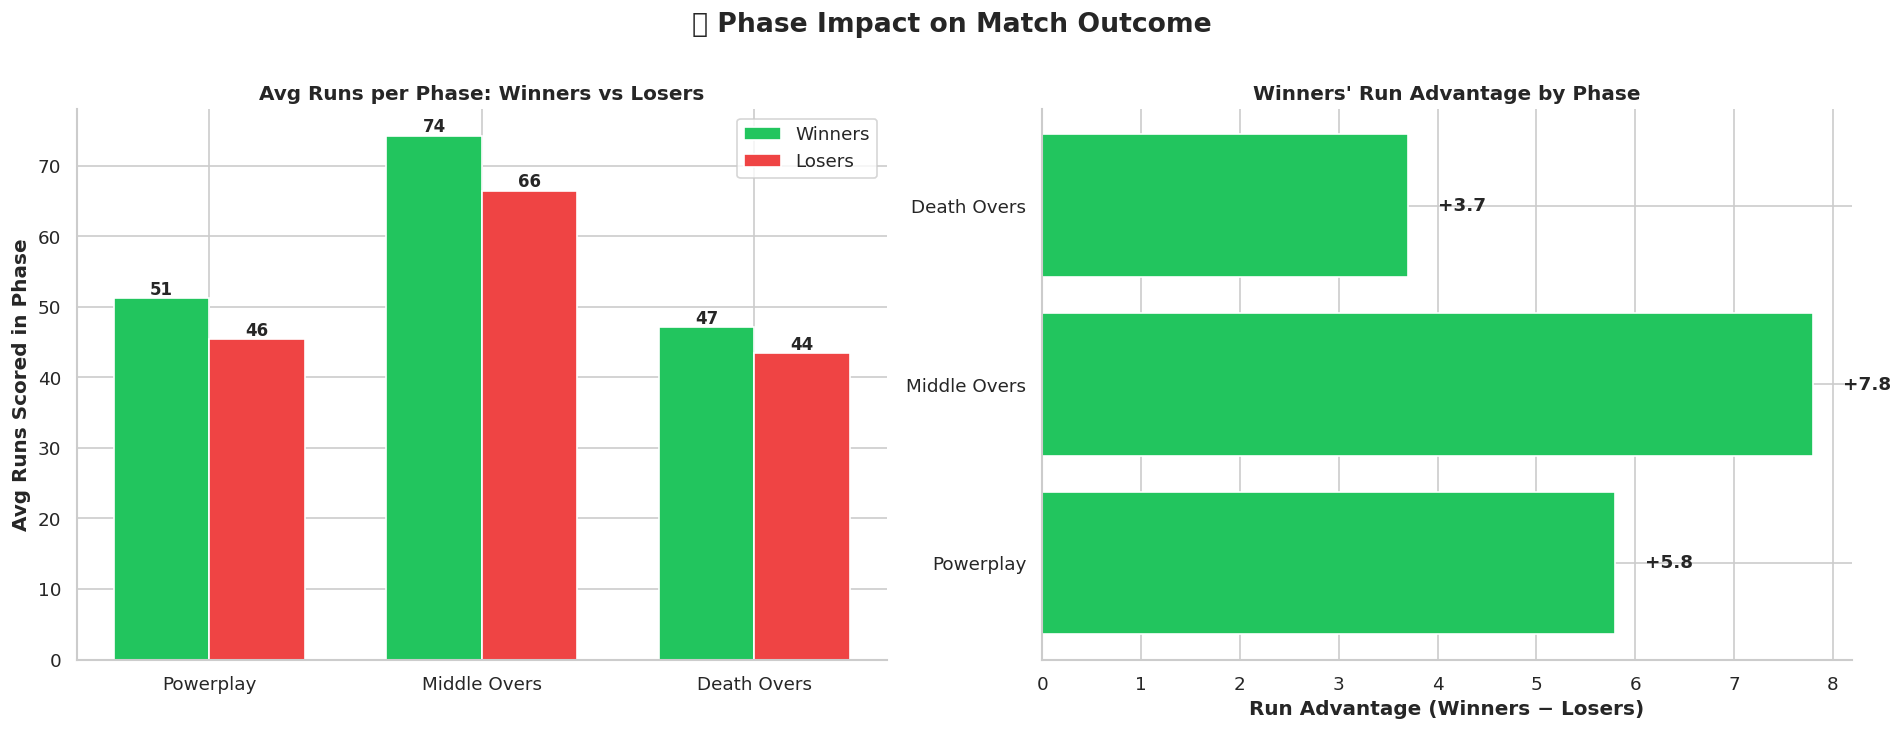

✅ Chart 2 saved — chart2_phase_impact.png


In [ ]:
# Visulaization: Grouped bar — avg runs per phase

PHASE_ORDER = ["Powerplay", "Middle Overs", "Death Overs"]
phase_pivot = phase_pivot.set_index("phase").loc[PHASE_ORDER].reset_index()

x = np.arange(len(PHASE_ORDER))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("🏏 Phase Impact on Match Outcome", fontsize=16, fontweight="bold", y=1.01)

# — Left: grouped bar
ax = axes[0]

b1 = ax.bar(
    x - width / 2,
    phase_pivot["Winners"],
    width,
    label="Winners",
    color=IPL_COLORS[2],
    edgecolor="white"
)

b2 = ax.bar(
    x + width / 2,
    phase_pivot["Losers"],
    width,
    label="Losers",
    color=IPL_COLORS[3],
    edgecolor="white"
)

ax.set_xticks(x)
ax.set_xticklabels(PHASE_ORDER, fontsize=11)
ax.set_ylabel("Avg Runs Scored in Phase")
ax.set_title("Avg Runs per Phase: Winners vs Losers")
ax.legend()

for bar in b1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

for bar in b2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# — Right: run advantage (gap chart)
ax2 = axes[1]

colors_adv = [
    IPL_COLORS[2] if v > 0 else IPL_COLORS[3]
    for v in phase_pivot["run_advantage"]
]

bars3 = ax2.barh(
    phase_pivot["phase"],
    phase_pivot["run_advantage"],
    color=colors_adv,
    edgecolor="white"
)

ax2.axvline(0, color="black", linewidth=1)
ax2.set_xlabel("Run Advantage (Winners − Losers)")
ax2.set_title("Winners' Run Advantage by Phase")

for bar, val in zip(bars3, phase_pivot["run_advantage"]):
    ax2.text(
        val + (0.3 if val >= 0 else -0.3),
        bar.get_y() + bar.get_height() / 2,
        f"+{val:.1f}" if val >= 0 else f"{val:.1f}",
        va="center",
        fontweight="bold",
        fontsize=11
    )

plt.tight_layout()
plt.savefig("chart2_phase_impact.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Chart 2 saved — chart2_phase_impact.png")

## 🧠 Phase Impact — Key Insights

### 📌 Average Phase Performance
- 🏏 Powerplay: Winners (51.3) vs Losers (45.5)
- 🏏 Middle Overs: Winners (74.3) vs Losers (66.5)
- 🏏 Death Overs: Winners (47.2) vs Losers (43.5)

👉 Winners consistently outperform losers in all phases.

---

### 📊 Run Advantage Ranking
1. 🥇 Middle Overs → **+7.8 runs**
2. 🥈 Powerplay → **+5.8 runs**
3. 🥉 Death Overs → **+3.7 runs**

---

### 🏁 Final Insight
👉 The **Middle Overs** is the most decisive phase of the match.

Teams that control the middle overs gain the biggest advantage and are more likely to win matches.

### ===========================================================
## 🏆 Section 7 — ANALYSIS 3: TOP PLAYERS (LAST 5 SEASONS)
### ===========================================================

### 🎯 Objective
- Identify the top 5 batters (by runs) and top 5 bowlers
(by wickets) across the last 5 IPL seasons.
- Include strike rate / economy as secondary quality metric.


In [ ]:
# Top Batters

# Legal deliveries for strike rate (exclude wides)
df_bat = df_5s[df_5s["extras_wides"] == 0].copy()

batter_stats = (
    df_bat.groupby("batter")
    .agg(
        total_runs     = ("runs_batter", "sum"),
        balls_faced    = ("runs_batter", "count"),
        innings_played = ("match_id", "nunique"),
        fours          = ("runs_batter", lambda x: (x == 4).sum()),
        sixes          = ("runs_batter", lambda x: (x == 6).sum()),
    )
    .reset_index()
)
batter_stats["strike_rate"] = (
    batter_stats["total_runs"] / batter_stats["balls_faced"] * 100
).round(1)

# Min 200 balls for qualifying
top_batters = (
    batter_stats[batter_stats["balls_faced"] >= 200]
    .sort_values("total_runs", ascending=False)
    .head(5)
    .reset_index(drop=True)
)
top_batters.index += 1   # rank 1–5

print("\n🏅 TOP 5 BATTERS (Last 5 Seasons):")
print(top_batters[["batter","total_runs","balls_faced","strike_rate","fours","sixes"]].to_string())

# Top Bowlers

# Wicket delivery = wicket_player_out is not null,
# exclude run-outs (credited to fielder, not bowler)
df_wkt = df_5s[
    df_5s["wicket_player_out"].notna() &
    (~df_5s["wicket_kind"].isin(["run out", "retired hurt", "obstructing the field"]))
].copy()

# Legal deliveries for bowler (exclude no-balls too for economy)
df_bowl = df_5s.copy()
df_bowl["legal"] = (df_5s["extras_wides"] == 0) & (df_5s["extras_noballs"] == 0)

bowler_stats = (
    df_bowl.groupby("bowler")
    .agg(
        legal_balls     = ("legal", "sum"),
        runs_conceded   = ("runs_total", "sum"),
        matches         = ("match_id", "nunique"),
    )
    .reset_index()
)

wicket_counts = (
    df_wkt.groupby("bowler")["wicket_player_out"]
    .count()
    .reset_index()
    .rename(columns={"wicket_player_out": "wickets"})
)

bowler_stats = bowler_stats.merge(wicket_counts, on="bowler", how="left")
bowler_stats["wickets"] = bowler_stats["wickets"].fillna(0).astype(int)
bowler_stats["overs_bowled"] = (bowler_stats["legal_balls"] / 6).round(1)
bowler_stats["economy"] = (
    bowler_stats["runs_conceded"] / bowler_stats["overs_bowled"]
).round(2)

# Min 10 overs bowled
top_bowlers = (
    bowler_stats[bowler_stats["overs_bowled"] >= 10]
    .sort_values("wickets", ascending=False)
    .head(5)
    .reset_index(drop=True)
)
top_bowlers.index += 1

print("\n🏅 TOP 5 BOWLERS (Last 5 Seasons):")
print(top_bowlers[["bowler","wickets","overs_bowled","economy","matches"]].to_string())


🏅 TOP 5 BATTERS (Last 5 Seasons):
         batter  total_runs  balls_faced  strike_rate  fours  sixes
1  Shubman Gill        2827         1879        150.5    270    100
2       V Kohli        2757         1913        144.1    267     96
3    JC Buttler        2487         1665        149.4    248    112
4      KL Rahul        2401         1688        142.2    215     98
5   YBK Jaiswal        2189         1401        156.2    261     94

🏅 TOP 5 BOWLERS (Last 5 Seasons):
           bowler  wickets  overs_bowled  economy  matches
1       YS Chahal       90         253.8     8.82       68
2  Arshdeep Singh       78         247.5     9.44       68
3     Rashid Khan       76         266.5     8.23       70
4        CV Varun       74         216.7     8.34       59
5         B Kumar       73         247.2     8.65       67


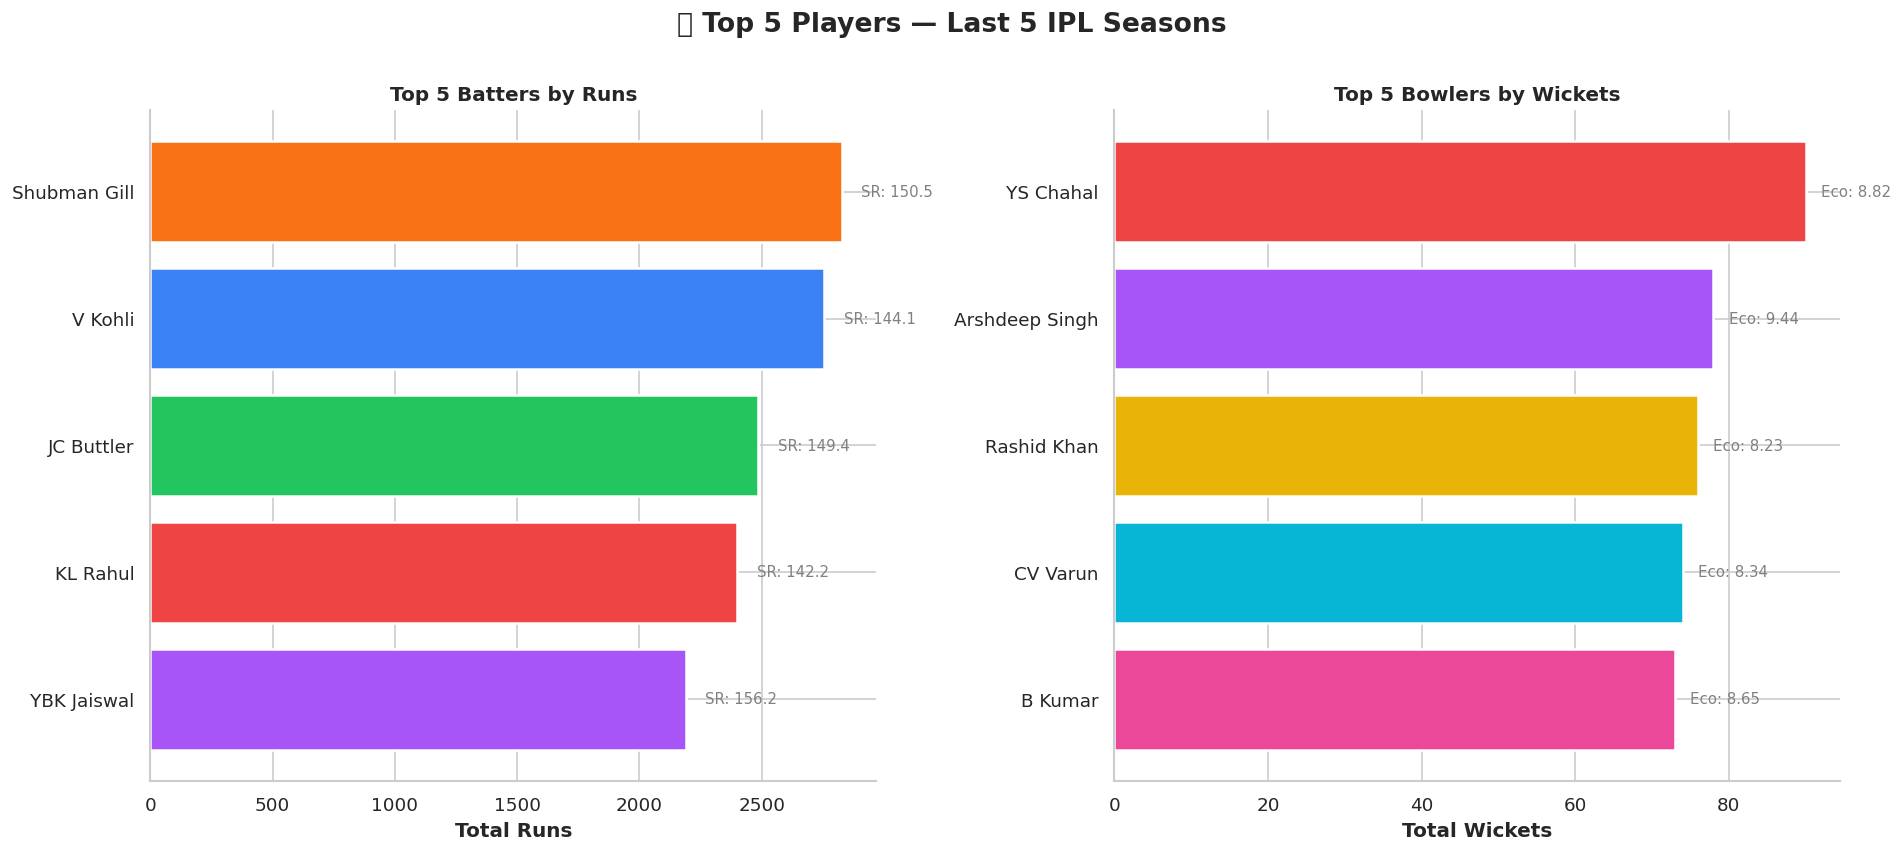

✅ Chart 3 saved — chart3_top_players.png


In [ ]:
# Visualisations - Top IPL Players (Last 5 Seasons)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("🏆 Top 5 Players — Last 5 IPL Seasons", fontsize=16, fontweight="bold", y=1.01)

# Batters
ax1 = axes[0]
bat_colors = IPL_COLORS[:5]
bars_bat = ax1.barh(
    top_batters["batter"][::-1],
    top_batters["total_runs"][::-1],
    color=bat_colors[::-1],
    edgecolor="white", linewidth=1.5
)
ax1.set_xlabel("Total Runs")
ax1.set_title("Top 5 Batters by Runs", fontweight="bold")
for bar, sr in zip(bars_bat, top_batters["strike_rate"][::-1]):
    ax1.text(
    bar.get_width() + 80,   # increased spacing
    bar.get_y() + bar.get_height()/2,
    f"SR: {sr}",
    va="center",
    fontsize=9,
    color="grey")


# Bowlers
ax2 = axes[1]
bowl_colors = IPL_COLORS[3:8]
bars_bowl = ax2.barh(
    top_bowlers["bowler"][::-1],
    top_bowlers["wickets"][::-1],
    color=bowl_colors[::-1],
    edgecolor="white", linewidth=1.5
)
ax2.set_xlabel("Total Wickets")
ax2.set_title("Top 5 Bowlers by Wickets", fontweight="bold")
for bar, eco in zip(bars_bowl, top_bowlers["economy"][::-1]):
    ax2.text(
    bar.get_width() + 2,   # more spacing
    bar.get_y() + bar.get_height()/2,
    f"Eco: {eco}",
    va="center",
    fontsize=9,
    color="grey"
)

plt.tight_layout()
plt.savefig("chart3_top_players.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved — chart3_top_players.png")

## 🧠 Top IPL Players (Last 5 Seasons) - Key Insights

### 🏏 Batting Impact
- Shubman Gill leads with **2827 runs**, followed closely by Kohli (**2757 runs**).
- All top batters maintain a strong strike rate (~142–156), showing a balance of **consistency + aggression**.
- Boundary contribution (4s + 6s) is a major differentiator among elite batters.

👉 Insight: Modern IPL batting is driven by **high-volume scorers with sustained strike rates above 140**.

---

### 🎯 Bowling Impact
- YS Chahal leads wicket-takers with **90 wickets**, followed by Arshdeep Singh (**78 wickets**).
- Economy rates stay within a tight range (~8.2–9.4), showing consistency across top bowlers.
- Wickets matter more than economy for ranking top performers.

👉 Insight: Elite bowlers win matches by **breaking partnerships regularly, not just restricting runs**.

---

### 🏆 Final Takeaway
👉 IPL success is defined by:
- High-volume, high-strike batters
- Wicket-taking bowlers in pressure situations
- Balanced all-round match impact rather than single metrics

### ===================================================================
## 💡 Section 8 — HIDDEN INSIGHT: THE DEATH-OVER CHASING TRAP
### ===================================================================

### 🎯 Objective

Uncover a non-obvious pattern in IPL data that most casual viewers would miss.


In [ ]:
# Death over runs: innings 1 vs innings 2

death_df = df[df["phase"] == "Death Overs"].copy()

death_innings = (
    death_df.groupby(["match_id", "innings", "batting_team"])["runs_total"]
    .sum()
    .reset_index()
    .rename(columns={"runs_total": "death_runs"})
)

death_innings = death_innings.merge(
    match_df[["match_id", "winner"]], on="match_id"
)
death_innings["won"] = death_innings["batting_team"] == death_innings["winner"]

death_summary = (
    death_innings.groupby("innings")
    .agg(
        avg_death_runs  = ("death_runs", "mean"),
        win_rate        = ("won", "mean"),
        count           = ("match_id", "count")
    )
    .round(2)
    .reset_index()
)
death_summary["win_rate_%"] = (death_summary["win_rate"] * 100).round(1)
death_summary["innings_label"] = death_summary["innings"].map(
    {1: "1st Innings (Bat first)", 2: "2nd Innings (Chase)"}
)

print("\n📊 Death Over Analysis — Innings 1 vs 2:")
print(death_summary[["innings_label","avg_death_runs","win_rate_%"]].to_string(index=False))

# Middle-over runs and their effect on chasing

# Split chasing teams by how many runs they scored in middle overs
middle_chase = df[
    (df["phase"] == "Middle Overs") & (df["innings"] == 2)
].groupby(["match_id", "batting_team"])["runs_total"].sum().reset_index()
middle_chase.columns = ["match_id", "batting_team", "middle_runs"]

middle_chase = middle_chase.merge(match_df[["match_id","winner"]], on="match_id")
middle_chase["won"] = middle_chase["batting_team"] == middle_chase["winner"]

# Bin into run brackets
middle_chase["middle_bracket"] = pd.cut(
    middle_chase["middle_runs"],
    bins=[0, 50, 70, 90, 200],
    labels=["≤50", "51–70", "71–90", ">90"]
)

bracket_win = (
    middle_chase.groupby("middle_bracket")["won"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"won": "chase_win_%"})
)
print("\n📊 Chase Win Rate by Middle-Over Runs Scored:")
print(bracket_win.to_string(index=False))


📊 Death Over Analysis — Innings 1 vs 2:
          innings_label  avg_death_runs  win_rate_%
1st Innings (Bat first)           50.52        45.0
    2nd Innings (Chase)           39.64        51.0

📊 Chase Win Rate by Middle-Over Runs Scored:
middle_bracket  chase_win_%
           ≤50         43.6
         51–70         49.2
         71–90         59.2
           >90         62.7


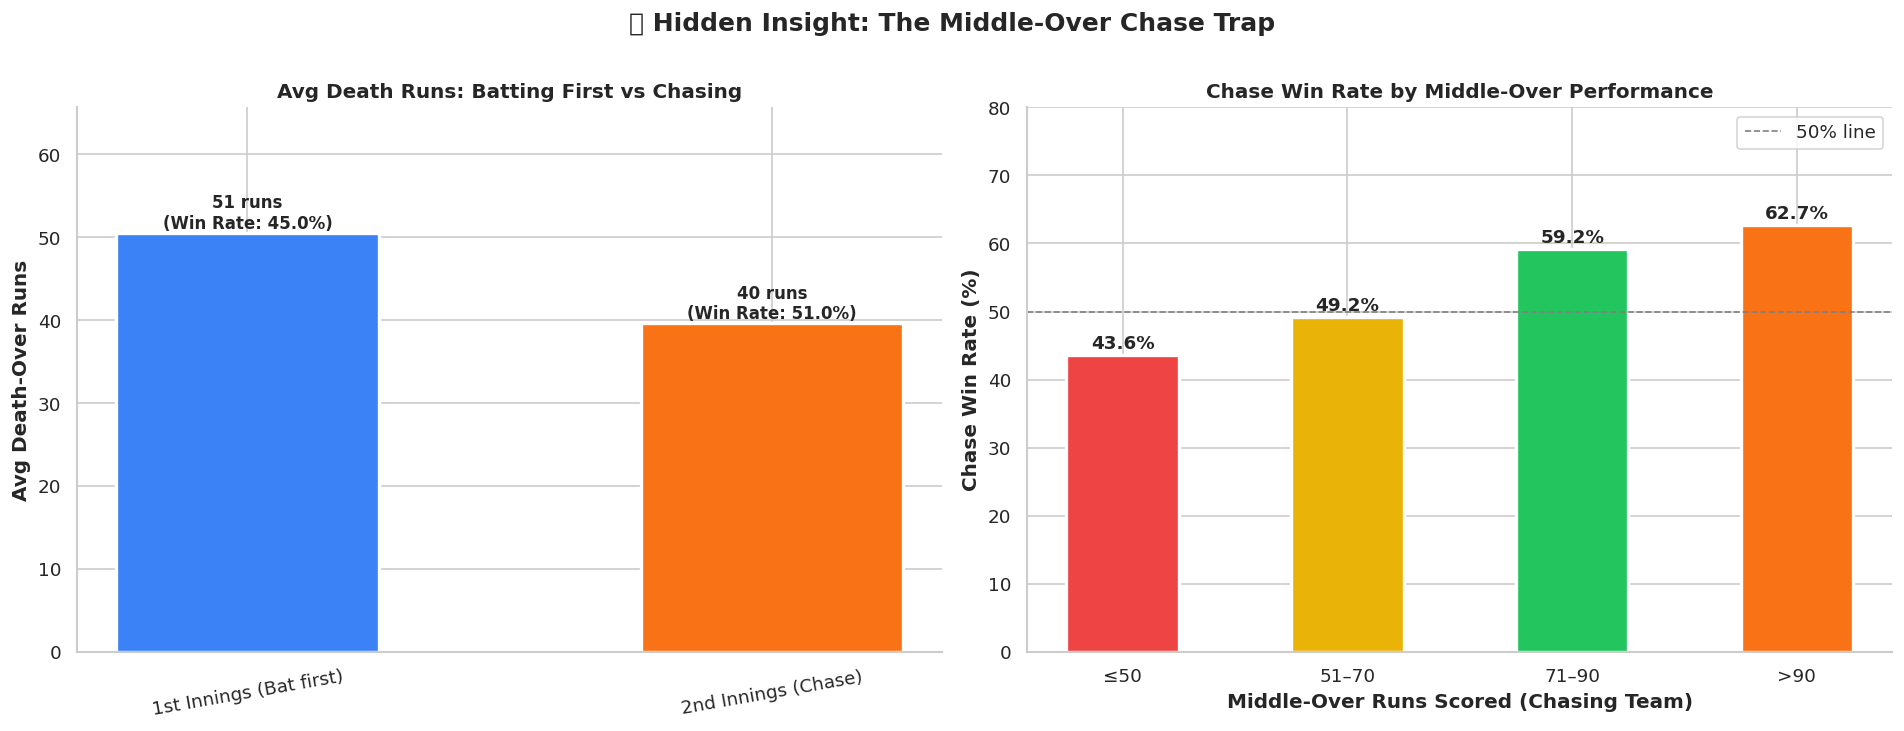

✅ Chart 4 saved — chart4_hidden_insight.png


In [ ]:
# 8.3 — Visualisation

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "💡 Hidden Insight: The Middle-Over Chase Trap",
    fontsize=15, fontweight="bold", y=1.01
)

# Left: death run comparison
ax1 = axes[0]
bars = ax1.bar(
    death_summary["innings_label"],
    death_summary["avg_death_runs"],
    color=[IPL_COLORS[1], IPL_COLORS[0]],
    width=0.5, edgecolor="white", linewidth=2
)
ax1.set_ylabel("Avg Death-Over Runs")
ax1.set_title("Avg Death Runs: Batting First vs Chasing")
for bar, wr in zip(bars, death_summary["win_rate_%"]):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.0f} runs\n(Win Rate: {wr}%)",
        ha="center", fontsize=10, fontweight="bold"
    )
ax1.set_ylim(0, death_summary["avg_death_runs"].max() * 1.3)
ax1.tick_params(axis="x", labelrotation=10)

# Right: middle bracket win rate
ax2 = axes[1]
bracket_colors = [IPL_COLORS[3], IPL_COLORS[5], IPL_COLORS[2], IPL_COLORS[0]]
bars2 = ax2.bar(
    bracket_win["middle_bracket"].astype(str),
    bracket_win["chase_win_%"],
    color=bracket_colors,
    width=0.5, edgecolor="white", linewidth=2
)
ax2.axhline(50, color="grey", linestyle="--", linewidth=1, label="50% line")
ax2.set_ylabel("Chase Win Rate (%)")
ax2.set_xlabel("Middle-Over Runs Scored (Chasing Team)")
ax2.set_title("Chase Win Rate by Middle-Over Performance")
ax2.legend()
for bar, val in zip(bars2, bracket_win["chase_win_%"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f"{val}%", ha="center", fontweight="bold", fontsize=11)
ax2.set_ylim(0, 80)

plt.tight_layout()
plt.savefig("chart4_hidden_insight.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved — chart4_hidden_insight.png")

### =============================================================
💡 SURPRISE FINDING
### =============================================================

Chasing teams don’t win because of death-over fireworks.

They win because of what happens much earlier:

👉 If a chasing team scores 71+ runs in overs 7–15,
   their win rate jumps to ~60–63%.

But if they fail in this phase (≤70 runs),
   their win rate drops below 50%, even if they finish strongly.

🔥 Final Insight:
The "death-over finish" is mostly a myth —
T20 chases are actually decided silently in the middle overs.


### ===================================================
## 🔬 SECTION 9 — ADVANCED HIDDEN INSIGHTS
### ===================================================

This section explores deeper IPL patterns that are not obvious
from traditional scorecards or commentary.

These insights uncover hidden strategic patterns inside IPL matches.


## 🎯 INSIGHT 1 — The Over-6 Wicket Rule

🎯 INSIGHT 1 — Over-6 Wicket Impact
              label  mean  median  count
No Wicket in Over 6  72.5    71.0    928
   Wicket in Over 6  65.4    64.0    288


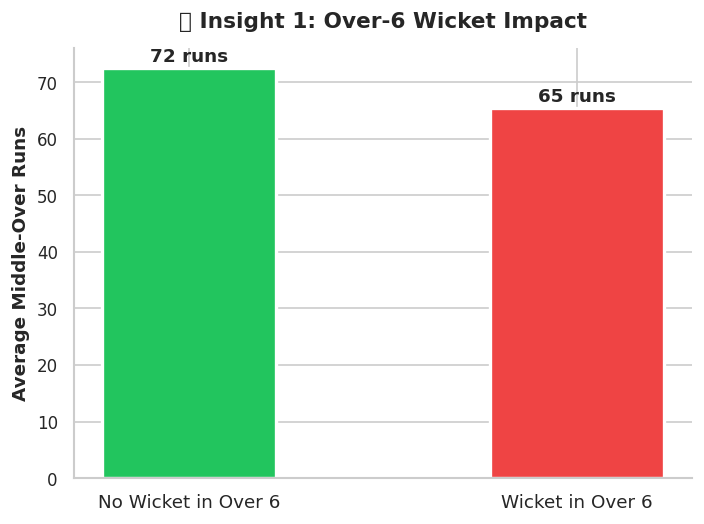

In [ ]:
# Ball 5 = over index 5 (0-based)
# Represents over 6 in T20 cricket

over6_wickets = df[
    (df["over"] == 5) &
    (df["innings"] == 1) &
    (df["wicket_player_out"].notna())
]["match_id"].unique()

# Middle-over runs in innings 1
middle_inn1 = df[
    (df["phase"] == "Middle Overs") &
    (df["innings"] == 1)
].groupby(["match_id", "batting_team"])["runs_total"].sum().reset_index()

middle_inn1.columns = ["match_id", "batting_team", "middle_runs"]

# Tag matches with over-6 wicket
middle_inn1["over6_wicket"] = middle_inn1["match_id"].isin(over6_wickets)

# Compare averages
over6_summary = (
    middle_inn1.groupby("over6_wicket")["middle_runs"]
    .agg(["mean", "median", "count"])
    .round(1)
    .reset_index()
)

over6_summary["label"] = over6_summary["over6_wicket"].map({
    True: "Wicket in Over 6",
    False: "No Wicket in Over 6"
})

print("🎯 INSIGHT 1 — Over-6 Wicket Impact")
print(over6_summary[["label", "mean", "median", "count"]].to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(6, 4.5))

bars = ax.bar(
    over6_summary["label"],
    over6_summary["mean"],
    color=[IPL_COLORS[2], IPL_COLORS[3]],   # swapped colors
    width=0.45,
    edgecolor="white",
    linewidth=2
)

# Value labels
for bar, val in zip(bars, over6_summary["mean"]):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.4,
        f"{val:.0f} runs",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Labels and title
ax.set_ylabel(
    "Average Middle-Over Runs",
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "🎯 Insight 1: Over-6 Wicket Impact",
    fontsize=13,
    fontweight="bold",
    pad=12
)

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()

plt.savefig(
    "insight1_over6_wicket.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()